# k 近邻（kNN）：不训练也能分类

**课程 0005 配套练习** · 内核：`deeplearning`

前置：课程 0004。上一课逻辑回归在同心圆上无能为力——它的「模型」只有直线。
本课主角 kNN 完全不需要「训练」，却能把圆环切开。为什么？答案就在三要素里。

回忆三要素（李航）：
- **模型** = 候选函数集合
- **策略** = 判断好坏的标准
- **算法** = 怎么搜

> 读完后请回答：kNN 的「算法」和逻辑回归的「算法」有什么本质区别？


## 数据：逻辑回归切不开的同心圆

直接用课程 0004 练习 M2 的同心圆数据——内圈 y=0，外圈 y=1。


X 形状： (200, 2)   标签取值： [0 1]


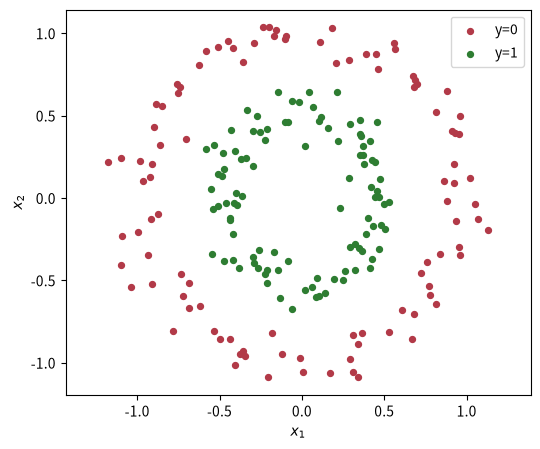

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体
import matplotlib as mpl
from matplotlib import font_manager
for name in ["Noto Sans CJK SC", "Noto Serif CJK SC", "WenQuanYi Zen Hei", "SimHei"]:
    if any(f.name == name for f in font_manager.fontManager.ttflist):
        mpl.rcParams["font.sans-serif"] = [name]
        break
mpl.rcParams["axes.unicode_minus"] = False

from sklearn.datasets import make_circles

X, y = make_circles(n_samples=200, noise=0.08, factor=0.5, random_state=0)
print("X 形状：", X.shape, "  标签取值：", np.unique(y))

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=18, label="y=0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=18, label="y=1")
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.show()

## 三要素之「模型」：没有参数，训练集就是模型

kNN 不学出任何 w、b。它的「模型」由三样东西组成：

1. **训练集本身**（所有样本点都是「原型」）
2. **距离度量**（怎么算「近」，默认欧氏距离）
3. **k**（看几个近邻）

预测新样本 x 时：找离 x 最近的 k 个训练样本，**少数服从多数**投票定标签。
因为「学」发生在预测时刻，kNN 也叫 **惰性学习（lazy learning）/ 实例学习（instance-based）**。

决策边界由样本密度决定，可以是<strong>任意形状</strong>——这正是它能切开圆环的原因。


## 三要素之「策略」：距离 + 多数投票

- **策略 = 评价标准**：分类时用「多数投票」（k 个近邻里哪个标签多）；回归时取平均。
- 距离度量本身也是策略的一部分：换曼哈顿距离，边界就会变。
- **超参数 k** 不在损失函数里，而是「用什么标准判近邻」——所以 k 用交叉验证来选，而不是梯度下降。

## 三要素之「算法」：暴力搜索（或 kd 树）

预测时对每个新点：算它到所有训练点的距离 → 排序取前 k → 投票。
大数据量下用 **kd 树** 加速（sklearn 可选），但思想不变。


## 手写 kNN（训练一次都没有！）

注意：下面的函数里没有任何 for 循环的「训练」——它只在预测时做事。


In [14]:
def predict_knn(X_train: np.ndarray, y_train: np.ndarray,
                X_test: np.ndarray, k: int) -> np.ndarray:
    """欧氏距离 + 多数投票。d 是 (n_test, n_train) 的距离矩阵。"""
    d = ((X_train[None, :, :] - X_test[:, None, :]) ** 2).sum(axis=-1)   # (n_test, n_train) 的距离矩阵
    # X_train[None, :, :] 形状 (1, n_train, n_features)，X_test[:, None, :] 形状 (n_test, 1, n_features)
    # 广播后得到 (n_test, n_train, n_features) 的差值矩阵，平方后按最后一维(axis = 2)求和得到距离矩阵 d
    
    idx = np.argsort(d, axis=-1)[:, :k]  # 得到每个测试样本的 k 个最近邻的索引[n_test, k]
    votes = y_train[idx]        # 得到每个测试样本的 k 个最近邻的标签[n_test, k]
    return np.array([np.bincount(v.astype(int)).argmax() for v in votes])   # bincount:统计每个标签出现的次数，argmax:返回出现次数最多的标签,

acc = float(np.mean(predict_knn(X, y, X, k=5) == y))
print(f"k=5 在训练集上的回代准确率：{acc:.3f}（这只是参考，真正看泛化要分 train/test）")

k=5 在训练集上的回代准确率：1.000（这只是参考，真正看泛化要分 train/test）


## 决策边界：任意形状

在平面上铺满网格点，让 kNN 逐个分类，画出边界。


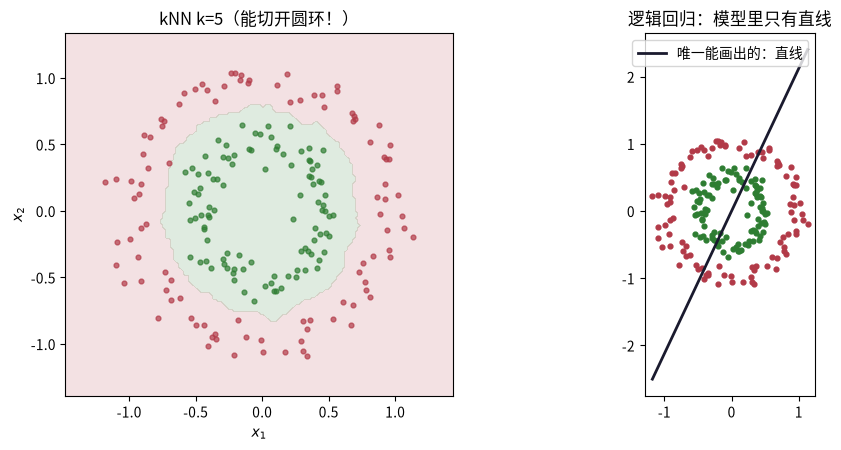

In [28]:
def plot_boundary(X, y, k, ax, title=None):
    x1 = np.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 150)
    x2 = np.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 150)
    xx, yy = np.meshgrid(x1, x2)        # 画多维图就是多了个这个网格化步骤
    Z = predict_knn(X, y, np.vstack([xx.ravel(), yy.ravel()]).T, k).reshape(xx.shape)   # n_test = xx.size不等于n_train = X.shape[0]
    ax.contourf(xx, yy, Z, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.15)
    # contourf填充等高区域，levels=1只画一条分界线分成两大块，红色代表类别 0 区域、绿色代表类别 1 区域，透明度 0.15 避免遮挡散点。
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=12, alpha=0.7)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=12, alpha=0.7)
    ax.set_title(title or f"k = {k}"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")      # 比例一致

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
plot_boundary(X, y, 5, axes[0], "kNN k=5（能切开圆环！）")
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(X, y)
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
w, b = lr.coef_.ravel(), lr.intercept_[0]
x2 = -(w[0] * x1 + b) / w[1]
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], c="#b23a48", s=12)
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], c="#2e7d32", s=12)
axes[1].plot(x1, x2, color="#1a1a2e", lw=2, label="唯一能画出的：直线")
axes[1].set_title("逻辑回归：模型里只有直线"); axes[1].legend(); axes[1].set_aspect("equal")
plt.tight_layout(); plt.show()

## k 的选择：又一次偏差-方差权衡

- **k 太小**（如 1）：只看最近一个点 → 对噪声敏感，边界锯齿状 → **过拟合**
- **k 太大**（如 200）：边界太平滑，把细节都抹掉 → **欠拟合**
- k 是**超参数**：用交叉验证在验证集上选，而不是训练得到。

这正是课程 0003 的偏差-方差权衡在 kNN 里的版本。


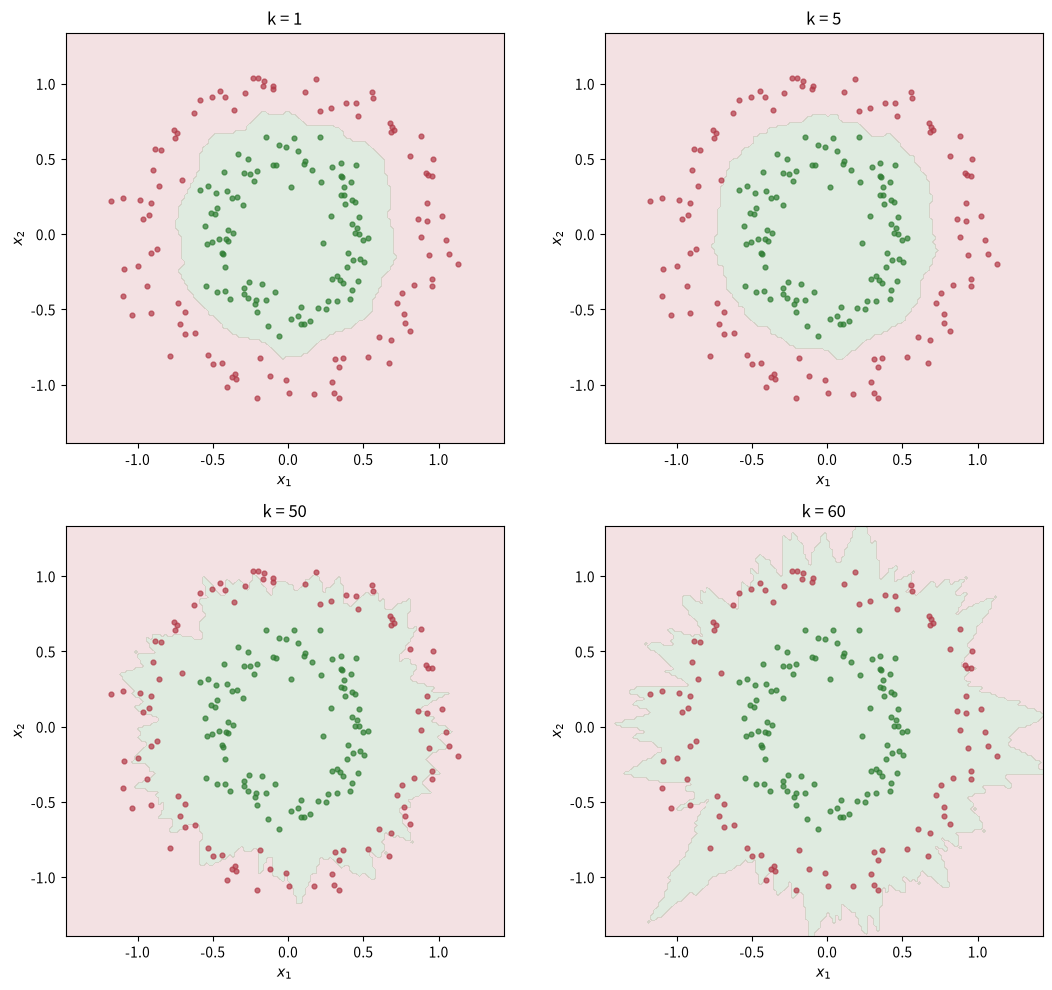

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, k in zip(axes.ravel(), [1, 5, 50, 60]):
    plot_boundary(X, y, k, ax, f"k = {k}")
plt.tight_layout(); plt.show()

## 特征缩放：距离的隐藏陷阱

距离「近不近」取决于每个特征的量纲。如果 $x_1$ 范围是 0~1000、$x_2$ 范围是 0~1，
距离会被 $x_1$ 完全主导——$x_2$ 的信息就废了。<strong>先标准化（减去均值、除以标准差），再算距离</strong>。


未缩放  test acc = 0.556
已缩放  test acc = 0.922


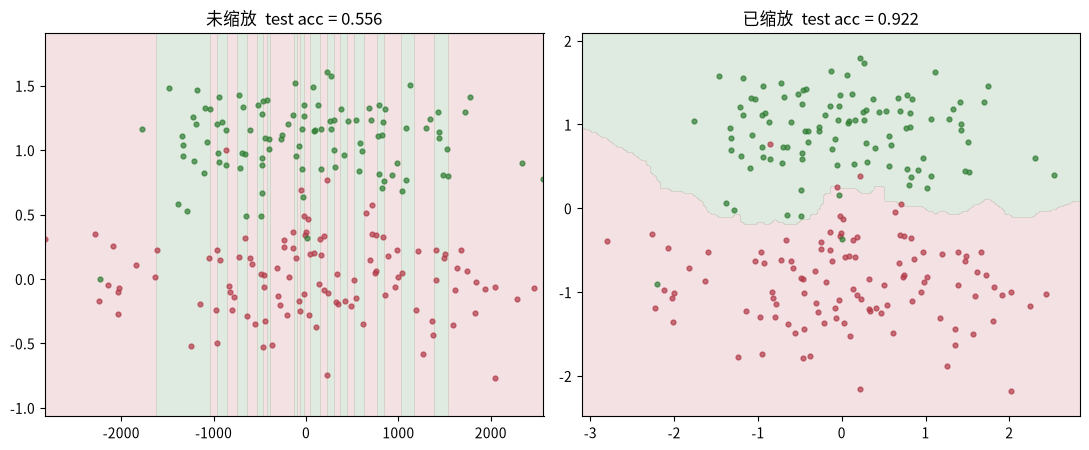

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(3)
n = 150
# 类 0 与类 1 只在 x2 上分开；x1 是纯噪声
Xraw = np.vstack([
    rng.normal([0, 0.0], [1.0, 0.3], (n, 2)),       # 二维正态分布，均值为 [0, 0]，协方差矩阵为 [[1.0, 0], [0, 0.3^2]]，生成 n 个样本
    rng.normal([0, 1.0], [1.0, 0.3], (n, 2)),
])
yraw = np.concatenate([np.zeros(n), np.ones(n)])
X_bad = Xraw * np.array([1000.0, 1.0])          # 人为放大 x1 量纲
X_std = StandardScaler().fit_transform(Xraw)     # 标准化

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_bad, yraw, test_size=0.3, random_state=0)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_std, yraw, test_size=0.3, random_state=0)

acc_bad = float(np.mean(predict_knn(Xb_tr, yb_tr, Xb_te, k=5) == yb_te))
acc_std = float(np.mean(predict_knn(Xs_tr, ys_tr, Xs_te, k=5) == ys_te))
print(f"未缩放  test acc = {acc_bad:.3f}")
print(f"已缩放  test acc = {acc_std:.3f}")

x1 = np.linspace(Xb_tr[:, 0].min() - 0.3, Xb_tr[:, 0].max() + 0.3, 150)
x2 = np.linspace(Xb_tr[:, 1].min() - 0.3, Xb_tr[:, 1].max() + 0.3, 150)
xx, yy = np.meshgrid(x1, x2)        # 画多维图就是多了个这个网格化步骤
Z_bad = predict_knn(Xb_tr, yb_tr, np.vstack([xx.ravel(), yy.ravel()]).T, k=5).reshape(xx.shape)
x1 = np.linspace(Xs_tr[:, 0].min() - 0.3, Xs_tr[:, 0].max() + 0.3, 150)
x2 = np.linspace(Xs_tr[:, 1].min() - 0.3, Xs_tr[:, 1].max() + 0.3, 150)
xx_s, yy_s = np.meshgrid(x1, x2)        # 这里的 xx, yy 是新的网格化坐标，和上面 Z_bad 的网格化坐标不同
Z_std = predict_knn(Xs_tr, ys_tr, np.vstack([xx_s.ravel(), yy_s.ravel()]).T, k=5).reshape(xx_s.shape)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].contourf(xx, yy, Z_bad, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.15)
axes[0].scatter(Xb_tr[yb_tr == 0, 0], Xb_tr[yb_tr == 0, 1], c="#b23a48", s=12, alpha=0.7)
axes[0].scatter(Xb_tr[yb_tr == 1, 0], Xb_tr[yb_tr == 1, 1], c="#2e7d32", s=12, alpha=0.7)
axes[0].set_title("未缩放  test acc = %.3f" % acc_bad); 
# axes[0].set_aspect("equal")
axes[1].contourf(xx_s, yy_s, Z_std, levels=1, colors=["#b23a48", "#2e7d32"], alpha=0.15)
axes[1].scatter(Xs_tr[ys_tr == 0, 0], Xs_tr[ys_tr == 0, 1], c="#b23a48", s=12, alpha=0.7)
axes[1].scatter(Xs_tr[ys_tr == 1, 0], Xs_tr[ys_tr == 1, 1], c="#2e7d32", s=12, alpha=0.7)
axes[1].set_title("已缩放  test acc = %.3f" % acc_std); 
axes[1].set_aspect("equal")
plt.tight_layout(); plt.show()

## 练习（S 理解 / M 动手 / H 挑战）

**S1.** k=1 时边界为什么锯齿状？把 `make_circles` 的 `noise` 调到 0.3，重画 k=1 和 k=50 的边界，观察准确率变化。这对应偏差还是方差？

**S2.** 改用 `make_moons(noise=0.1)` 数据集重画边界。同样是线性不可分，kNN 的边界是什么形状？

**M1.** 上面特征缩放实验里，把 `np.array([1000.0, 1.0])` 的 1000 改成 1，未缩放还会那么差吗？为什么？再想想：缩放对逻辑回归重要吗？（提示：梯度下降的收敛速度）

**M2.** 用 sklearn 的 `KNeighborsClassifier(n_neighbors=5)` 复现上面结果，并对比 `algorithm="kd_tree"` 与默认暴力搜索在 `make_blobs` 大样本（n=50000）下的耗时。

**H1.** 实现曼哈顿距离版 kNN：距离 = Σ|x₁−x₂|。在同心圆和月牙两个数据集上和欧氏距离对比准确率，结论是什么？

**H2.** 手动做交叉验证选 k：把训练集再分成 80/20（train/val），k 从 1 扫到 120，画出「k vs 验证集准确率」曲线，指出最佳 k，并用偏差-方差解释曲线的形状。


In [7]:
pass  # 练习区（S1/S2）

In [8]:
pass  # 练习区（M1/M2）

In [9]:
pass  # 练习区（H1/H2）

## 小结：kNN vs 逻辑回归

| | kNN | 逻辑回归 |
|---|---|---|
| 模型 | 训练集+距离+k（无参数） | σ(wᵀx+b)（参数化） |
| 策略 | 多数投票 / 平均 | 交叉熵 |
| 算法 | 预测时暴力搜索 | 训练时梯度下降 |
| 边界 | 任意形状 | 直线 |
| 需要的样本 | 越多越好（惰性，预测慢） | 较少（参数少） |
| 可解释性 | 看邻居即可解释 | 看权重即可解释 |

下一课：**朴素贝叶斯**——把「概率」从逻辑回归扩展到「特征的联合概率」，换一个生成式的视角。
